In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings(
    "ignore", category=FutureWarning
)  # to avoid deprecation warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import re

# Détecteur de spams

Qu'est-ce qu'un ham ? A l'inverse du spam, le ham est un courrier que l'on désire recevoir.

## Préparation de l'environnement

In [19]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("spam.csv", encoding='latin-1')
print("...Done.")

Loading dataset...
...Done.


## Charger les données & EDA

- Vérifier format, nombres d’exemples par classe (spam/ham), longueur des messages, exemples typiques.
- Visualiser déséquilibre de classes (barplot), distribution de longueurs.

In [20]:
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de classe : {}".format(dataset['v1'].nunique()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)

# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 5572
Nombre de colonnes : 5
Nombre de classe : 2
Aperçu du dataset : 


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Types de données/colonnes : 


v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object


 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
Unnamed: 2,5522,99.10
Unnamed: 3,5560,99.78
Unnamed: 4,5566,99.89


In [22]:
# STATISTIQUES DESCRIPTIVES

# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [23]:
# Conserver uniquement les colonnes v1, v2
dataset = dataset[['v1', 'v2']].copy()

# Renommer les colonnes pour plus de clarté
dataset.columns = ['label', 'message']


RÉPARTITION DES CLASSES (ham/spam)
----------------------------------------
label
ham     4825
spam     747
Name: count, dtype: int64

Pourcentages :
label
ham     86.59
spam    13.41
Name: count, dtype: float64

STATISTIQUES SUR LA LONGUEUR DES MESSAGES
----------------------------------------
        count    mean    std   min    25%    50%    75%    max
label                                                         
ham    4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0


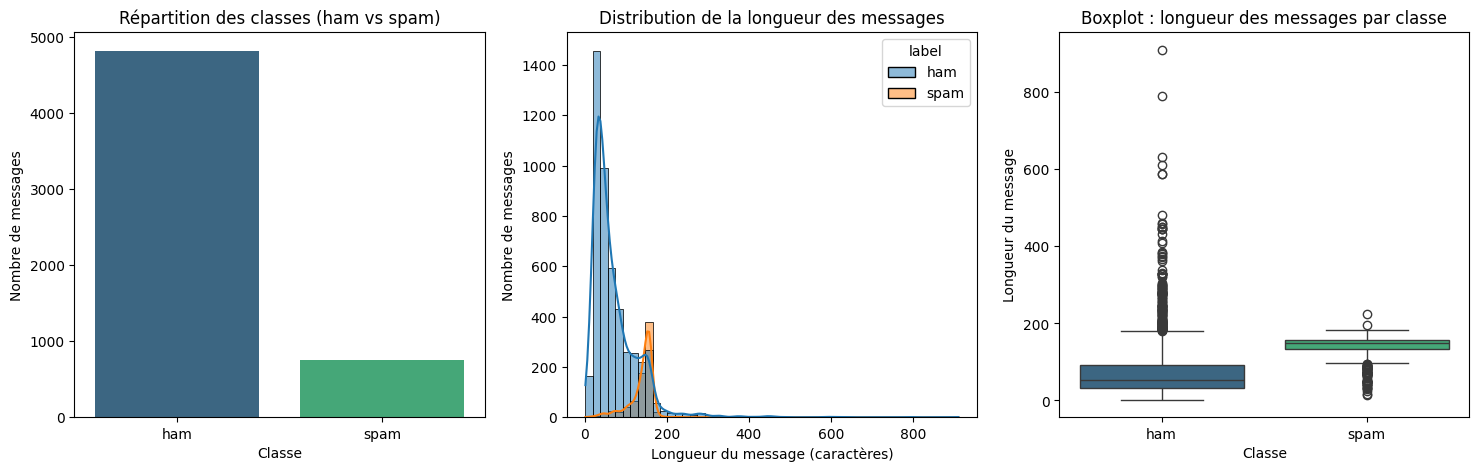


EXEMPLES TYPIQUES
----------------------------------------

--- HAM ---
['I am late,so call you tomorrow morning.take care sweet dreams....u and me...ummifying...bye.'
 'U r too much close to my heart. If u go away i will be shattered. Plz stay with me.'
 'Wait  &lt;#&gt;  min..']

--- SPAM ---
['Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804'
 'This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate '
 'Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just å£1.50 per wk 2 opt out send STOP 08452810071 16']


In [24]:
# Vérifier les classes
print("\nRÉPARTITION DES CLASSES (ham/spam)")
print("-"*40)
class_counts = dataset['label'].value_counts()
print(class_counts)
print("\nPourcentages :")
print(round((class_counts / len(dataset)) * 100, 2))

# Calcul de la longueur des messages
dataset['message_length'] = dataset['message'].apply(len)

# Statistiques descriptives sur la longueur
print("\nSTATISTIQUES SUR LA LONGUEUR DES MESSAGES")
print("-"*40)
print(dataset.groupby('label')['message_length'].describe().round(2))

# === VISUALISATIONS (1 colonne, 3 graphiques) ===
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
plt.subplots_adjust(hspace=0.4)

# Répartition des classes
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=None,    
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("Répartition des classes (ham vs spam)")
axes[0].set_ylabel("Nombre de messages")
axes[0].set_xlabel("Classe")

# Distribution de la longueur des messages
sns.histplot(
    data=dataset,
    x='message_length',
    hue='label',
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribution de la longueur des messages")
axes[1].set_xlabel("Longueur du message (caractères)")
axes[1].set_ylabel("Nombre de messages")

# Boxplot des longueurs par classe
sns.boxplot(
    data=dataset,
    x='label',
    y='message_length',
    hue=None,      
    palette='viridis',
    ax=axes[2]
)
axes[2].set_title("Boxplot : longueur des messages par classe")
axes[2].set_xlabel("Classe")
axes[2].set_ylabel("Longueur du message")

plt.show()

# Exemples typiques
print("\nEXEMPLES TYPIQUES")
print("-"*40)
print("\n--- HAM ---")
print(dataset[dataset['label'] == 'ham']['message'].sample(3, random_state=42).values) # Exemple sur 3 messages
print("\n--- SPAM ---")
print(dataset[dataset['label'] == 'spam']['message'].sample(3, random_state=42).values) # Exemple sur 3 messages



##### Interprétation des résultats

- RÉPARTITION DES CLASSES (ham/spam)
  - Le dataset contient plus de "ham" que de spams.
  - Le jeu de données est déséquilibré.
  - Conséquence : le modèle risque de favoriser la classe majoritaire (ham) si l'on ne fait rien. Pour réaliser la détection il faudra veiller à introduire un poids de classe équilibré (class_weight='balanced' dans LogisticRegression) ou  faire du resampling (sur-échantillonage des spams ou sous échantillonnage des hams).

- STATISTIQUES SUR LA LONGUEUR DES MESSAGES
  - Les spams sont en moyenne 2× plus longs que les hams (moy spams = 138.87 caractères // ham = 71)
  - Les hams sont plus variés en longueur (std = 58) que les spams (std = 29)
  - Le maximum 910 chez les hams montre qu’il existe quelques messages très longs.
  - En revanche, les spams plafonnent autour de 224 caractères → très standardisés.

- Conclusion
  - Déséquilibre des classes -> Nécessite un ajustement pendant l’entraînement pour éviter un biais vers les hams.
  - Longueur moyenne plus élevée chez les spams -> Bon indicateur discriminant → une feature simple comme “longueur du message” pourrait aider à la classification.
  - Variance plus forte chez les hams ->Les hams couvrent une grande diversité de messages (discussions, réponses courtes, etc.).

--> La différence de longueur de message spam/hma est elle réellement significative ? 

In [25]:
# Séparer les longueurs par classe
ham_lengths = dataset[dataset['label'] == 'ham']['message_length']
spam_lengths = dataset[dataset['label'] == 'spam']['message_length']

# Test t de Student (moyennes indépendantes)
t_stat, p_value = ttest_ind(spam_lengths, ham_lengths, equal_var=False)

print("\nTEST STATISTIQUE : Comparaison des longueurs de messages (spam vs ham)")
print("-"*65)
print(f"Statistique t : {t_stat:.3f}")
print(f"Valeur p      : {p_value:.6f}")

# Interprétation
alpha = 0.05
if p_value < alpha:
    print(f"Différence significative (p < {alpha}) : les spams ont une longueur différente des hams.")
else:
    print(f"Aucune différence significative (p >= {alpha}) : les longueurs ne diffèrent pas statistiquement.")



TEST STATISTIQUE : Comparaison des longueurs de messages (spam vs ham)
-----------------------------------------------------------------
Statistique t : 50.046
Valeur p      : 0.000000
Différence significative (p < 0.05) : les spams ont une longueur différente des hams.


- t-test indépendant : compare les moyennes de deux groupes (ici spam vs ham).
- Hypothèse nulle H0 : les longueurs moyennes sont identiques.
- Si p < 0.05, on rejette H0, donc il y a une différence significative.

## Prétraitement minimal

- Nettoyage : minuscules, suppression d’espaces superflus, normalisation numérique en tokens (<URL>, <PHONE>, <NUM>).
- Pas de suppression de la ponctuation(les signes comme !!! peuvent être utiles pour indiquer si spam).
- Tokenization compatible modèle (pour TF-IDF simple : scikit-learn; pour BERT : tokenizer HuggingFace).

In [27]:
def preprocess_text(text):
    """
    Prétraitement minimal des messages :
    - Mise en minuscules
    - Suppression des espaces superflus
    - Normalisation :
        * URLs → <URL>
        * N° de téléphone → <PHONE>
        * Nombres → <NUM>
    - (Ponctuation conservée sauf cas extrêmes)
    """

    # Mise en minuscules
    text = text.lower()

    # Normalisation des URLs
    text = re.sub(r'http\S+|www\S+', '<URL>', text)

    # Normalisation des numéros de téléphone
    text = re.sub(r'\b(\+?\d[\d\-\s]{7,}\d)\b', '<PHONE>', text)

    # Normalisation des nombres isolés
    text = re.sub(r'\b\d+(\.\d+)?\b', '<NUM>', text)

    # Suppression des espaces superflus
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Application du prétraitement
dataset['clean_message'] = dataset['message'].apply(preprocess_text)

# Aperçu avant/après
print("\nEXEMPLES AVANT/APRÈS PRÉTRAITEMENT")
print("-"*40)
for i in range(3):
    print(f"\nOriginal  : {dataset['message'].iloc[i]}")
    print(f"Nettoyé   : {dataset['clean_message'].iloc[i]}")



EXEMPLES AVANT/APRÈS PRÉTRAITEMENT
----------------------------------------

Original  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Nettoyé   : go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...

Original  : Ok lar... Joking wif u oni...
Nettoyé   : ok lar... joking wif u oni...

Original  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Nettoyé   : free entry in <NUM> a wkly comp to win fa cup final tkts 21st may <NUM>. text fa to <NUM> to receive entry question(std txt rate)t&c's apply 08452810075over18's


## Baseline rapide

- TF-IDF (unigram+bigram) + LogisticRegression (ou LinearSVC) — très rapide, très souvent performant.
- Mesures: accuracy, precision, recall, F1, ROC-AUC.
- Validation : stratified train/test split (ex. 80/20) + éventuellement cross-val stratifié.

## Modèles Deep Learning

- Embedding + BiLSTM (Keras/TensorFlow) ou CNN textuel : utile si tu veux entraîner depuis zéro.
- Réduction overfit : dropout, early stopping.

## Apprentissage par transfert ?? 

- Fine-tune un transformer pré-entraîné (ex. distilbert-base-uncased ou bert-base-uncased via HuggingFace) pour classification binaire — généralement meilleur que réseaux entraînés from-scratch sur petits datasets.
- Si messages en français, utiliser camembert, flaubert, ou mBERT/XLM-RoBERTa.

## Traitement du déséquilibre
- Peser la classe minoritaire via class_weight ou suréchantillonner (SMOTE pas idéal sur texte brut) ; en transfert, utiliser pos_weight/class_weight.


## Evaluation finale

- Matrice de confusion, courbe ROC, PR curve (utile si classes très déséquilibrées).
- Examiner faux positifs & faux négatifs — souvent instructif pour règles heuristiques.
- Interprétabilité / règles complémentaires
- SHAP/LIME pour expliquer prédictions (surtout pour BERT c’est utile).
- Compléter par règles simples (regex) pour capturer patterns évidents (ex. lots de liens courts, codes malicieux) — hybide ML+rule souvent robuste en prod.
- Export / déploiement
- Sauvegarder modèle (TF/Keras .h5, PyTorch .pt, ou un pipeline scikit-learn avec joblib).
- Penser latence : DistilBERT ou modèle quantifié pour déploiement en temps réel.